In [523]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [524]:
# Геометрические и режимные параметры двигателя
D = 0.105              # диаметр цилиндра, м
S = 0.128              # ход поршня, м
n_mex = 0.85202        # механический КПД
n = 2300               # частота вращения, об/мин
icyl = 4               # число цилиндров
eps = 18               # степень сжатия
lamb = 0.309           # R/L

Hu = 42.6 * 1E6
lo = 495.2             # стехиометрическое количество воздуха
alpha_diz = 2.1917     # коэффициент избытка воздуха

In [525]:
# Параметры наддува
Tk = 368.5             # температура за компрессором, K
Pk = 2.988 * 1E5       # давление за компрессором, Па
Tog = 741.22           # температура отработавших газов, K
Pog = 2.7972 * 1E5     # давление отработавших газов, Па

In [526]:
# Молярные массы компонентов
ml_sp = {
    'N2':  0.028,
    'O2':  0.032,
    'CO2': 0.044,
    'H2O': 0.018
}

In [527]:
# Фазы газораспределения
Fi_ovik = 300   # угол открытия выпускного клапана
Fi_zvik = 580   # угол закрытия выпускного клапана
Fi_ovk = 495    # угол открытия впускного клапана
Fi_zvk = 37     # угол закрытия впускного клапана
muf_int = 0.00850   # макс. проходное сечение впускного клапана
muf_exh = 0.00809   # макс. проходное сечение выпускного клапана
Fi_ovt = 6          # угол опережения впрыска топлива

In [528]:
# Состав газа на впуске (воздух)
rin = {
    'N2': 0.79,
    'O2': 0.21,
    'CO2': 0,
    'H2O': 0
}
# Состав отработавших газов
rout = {
    'N2': 0.7212,
    'O2': 0.0959,
    'CO2': 0.0668,
    'H2O': 0.1161
}

In [529]:
# Физические константы
Rm = 8.314           # универсальная газовая постоянная
dFi = np.pi / 180    # приращение угла ПКВ (1° в радианах)
N = 757              # количество элементов в массивах

In [530]:
def Vol(Fi):
    """Текущий объём цилиндра, м³"""
    Ap = (np.pi * D ** 2) / 4
    Vh = Ap * S
    Vc = Vh / (eps - 1)
    Fi_rad = (Fi * np.pi) / 180
    V = Vc + Vh - (np.pi * D ** 2) / 4 * S / 2 * (
            1 - np.cos(Fi_rad) - lamb / 4 * (1 - np.cos(2 * Fi_rad))
        )
    return V

In [531]:
def diff_L(p, Fi):
    """Работа сжатия/расширения за 1° ПКВ"""
    dL_dphi = -p * (Vol(Fi + 1) - Vol(Fi)) / dFi
    return dL_dphi

In [532]:
def Q_w(T, P, Fi):
    """Теплопотери в стенки камеры сгорания (формула Вошни)"""
    T_p = 559.76
    T_k = 517.82
    T_c = 410
    delta = 1e-3
    Cm = S / 30 * n
    alpha = 77.9e-4 * Cm ** (1/3) * (P * T) ** 0.5
    SFi = S / 2 * (1 - np.cos(np.deg2rad(Fi)) - lamb / 4 * (1 - np.cos(np.deg2rad(2 * Fi))))

    Qw_c = -alpha * (T - T_c) * np.pi * D * (delta + SFi) * 30 / np.pi / n
    Qw_k = -alpha * (T - T_k) * np.pi * D * D / 4 * 30 / np.pi / n
    Qw_p = -alpha * (T - T_p) * 1.4 * np.pi * D * D / 4 * 30 / np.pi / n
    Q_w = Qw_c + Qw_k + Qw_p
    return Q_w

In [533]:
def calc_Cv(T, r_H2O, r_O2, r_N2, r_CO2):
    """Теплоёмкость при постоянном объёме (аппроксимация полиномами)"""
    A_H2O = [1397.28, 116.90, 349.69, -259.99, 112.47, -27.73, 3.05, 461.6]
    A_O2  = [654.56, 68.44, 264.35, -393.57, 246.48, -73.33, 8.47, 259.8]
    A_N2  = [739.29, -22.47, 227.21, -185.89, 70.01, -12.38, 0.77, 296.8]
    A_CO2 = [623.42, 642.051, -894.27, 1184.18, -917.66, 348.92, -50.60, 188.9]
    
    v = [r_H2O, r_O2, r_N2, r_CO2]
    Cv1 = [1, 1, 1, 1]
    theta = (T - 273.15) / 1000.0
    for i in range(7):
        Cv1[0] += A_H2O[i] * ml_sp['H2O'] * theta ** i
        Cv1[1] += A_O2[i]  * ml_sp['O2']  * theta ** i
        Cv1[2] += A_N2[i]  * ml_sp['N2']  * theta ** i
        Cv1[3] += A_CO2[i] * ml_sp['CO2'] * theta ** i
    Cv = sum(v[i] * Cv1[i] for i in range(4))
    return Cv

In [534]:
def dxdFi_wibe(Fi):
    """Скорость тепловыделения по двойной функции Вибе"""
    ksi1 = 0.0712          # доля предварительно перемешанного горения
    mt1 = 0.694            # показатель качества предварит. горения
    mv1 = 0.854            # показатель качества диффузионного горения
    Fi_c1 = 2.0            # продолжительность предварит. горения, °ПКВ
    Fi_z = 67.6            # общая продолжительность горения, °ПКВ
    TDC = 180
    Fi_start = TDC - Fi_ovt
    rel_angle = Fi - Fi_start
    if rel_angle < 0 or rel_angle > Fi_z:
        return 0.0
    # Предварительное горение
    dx_o = ksi1 * (mt1 / Fi_c1) * (rel_angle / Fi_c1) ** mt1 * np.exp(-mt1/(mt1+1) * (rel_angle / Fi_c1)**(mt1+1))
    # Диффузионное горение
    a = 6.908
    dx_d = (1 - ksi1) * a * ((mv1 + 1) / Fi_z) * (rel_angle / Fi_z) ** mv1 * np.exp(-a * (rel_angle / Fi_z)**(mv1+1))
    return dx_d + dx_o

In [535]:
def calc_muF(fi, index):
    """Эффективная площадь проходного сечения клапана"""
    if index == 'intake':
        Fi_o = Fi_ovk
        Fi_z = Fi_zvk + 720
        muf = muf_int
    elif index == 'output':
        Fi_o = Fi_ovik
        Fi_z = Fi_zvik
        muf = muf_exh
    else:
        return 0.0

    if fi <= Fi_o or fi >= Fi_z:
        muF = 0
    elif Fi_o < fi <= Fi_o + 90:
        muF = np.sin((fi - Fi_o) / 180 * np.pi) * muf
    elif Fi_o + 90 < fi <= Fi_z - 90:
        muF = muf
    elif Fi_z - 90 < fi <= Fi_z:
        muF = np.sin((fi - Fi_z + 180) / 180 * np.pi) * muf
    else:
        muF = 0
    return muF

In [536]:
def calculate_rc(M_mix, M_H2O, M_O2, M_N2, M_CO2):
    """Мольные доли компонентов в смеси"""
    return {
        'H2O': M_H2O / M_mix,
        'O2':  M_O2  / M_mix,
        'N2':  M_N2  / M_mix,
        'CO2': M_CO2 / M_mix
    }

In [537]:
def gas_exchange(Pc, Tc, Fi, index, M_mix, M_H2O, M_O2, M_N2, M_CO2):
    """Расчёт газообмена через клапаны (приток/отток энтальпии и компонентов)"""
    omega = 30 * n / np.pi   # рад/с

    if index == 'intake':
        Pfar = Pk
        Tfar = Tk
        r_far = rin
        Ml = 28.9e-3
    elif index == 'output':
        Pfar = Pog
        Tfar = Tog
        r_far = rout
        Ml = 28.29e-3
    else:
        return 0, {}

    if Pfar > Pc:
        direction = 1
        P_in = Pfar
        P_out = Pc
        T_in = Tfar
        r_far_cur = r_far
    else:
        direction = -1
        P_in = Pc
        P_out = Pfar
        T_in = Tc
        r_far_cur = calculate_rc(M_mix, M_H2O, M_O2, M_N2, M_CO2)

    k = 1 + Rm / (calc_Cv(T_in, r_far_cur['H2O'], r_far_cur['O2'], r_far_cur['N2'], r_far_cur['CO2']))
    Cp = k * calc_Cv(T_in, r_far_cur['H2O'], r_far_cur['O2'], r_far_cur['N2'], r_far_cur['CO2'])

    beta_crit = (2 / (k + 1)) ** (k / (k - 1))
    beta = P_out / P_in
    if beta <= beta_crit:
        psi = np.sqrt(2*k/(k-1) * (beta_crit**(2/k) - beta_crit**((k+1)/k)))
    else:
        psi = np.sqrt(2*k/(k-1) * (beta**(2/k) - beta**((k+1)/k)))

    rho_in = P_in / (T_in * Rm)
    dGdfi = direction * calc_muF(Fi, index) * psi * np.sqrt(P_in * rho_in) / omega
    dMdfi = dGdfi / Ml
    dHdfi = Cp * T_in * dMdfi

    dMi = {
        'H2O': r_far_cur['H2O'] * dMdfi,
        'O2':  r_far_cur['O2']  * dMdfi,
        'N2':  r_far_cur['N2']  * dMdfi,
        'CO2': r_far_cur['CO2'] * dMdfi
    }
    return dHdfi, dMi

In [538]:
def wp(P0, T0):
    """Расчёт одного цикла (720°) — возвращает давления, температуры, массы, объёмы"""
    Fi_start_cycle = Fi_zvk          # 37°
    total_len = Fi_start_cycle + 720 + 1

    P_arr = np.zeros((total_len, 1))
    T_arr = np.zeros((total_len, 1))
    M_dict = {
        'N2':      np.zeros((total_len, 1)),
        'O2':      np.zeros((total_len, 1)),
        'CO2':     np.zeros((total_len, 1)),
        'H2O':     np.zeros((total_len, 1)),
        'Mixture': np.zeros((total_len, 1))
    }

    V0 = Vol(Fi_start_cycle)
    M_total0 = P0 * V0 / (Rm * T0)
    M_dict['N2'][Fi_start_cycle]  = rin['N2'] * M_total0
    M_dict['O2'][Fi_start_cycle]  = rin['O2'] * M_total0
    M_dict['CO2'][Fi_start_cycle] = 0.0
    M_dict['H2O'][Fi_start_cycle] = 0.0
    M_dict['Mixture'][Fi_start_cycle] = M_total0
    P_arr[Fi_start_cycle] = P0
    T_arr[Fi_start_cycle] = T0

    qc = M_total0 / (lo * alpha_diz)   # цикловая подача топлива, моль
    print(f'Цикловая подача топлива, {qc:.7f} моль')

    for Fi in range(Fi_start_cycle, Fi_start_cycle + 720):
        mix = M_dict['Mixture'][Fi]
        if mix > 0:
            mu_H2O = M_dict['H2O'][Fi] / mix
            mu_O2  = M_dict['O2'][Fi]  / mix
            mu_N2  = M_dict['N2'][Fi]  / mix
            mu_CO2 = M_dict['CO2'][Fi] / mix
        else:
            mu_H2O = mu_O2 = mu_N2 = mu_CO2 = 0.0

        cv = calc_Cv(T_arr[Fi], mu_H2O, mu_O2, mu_N2, mu_CO2)

        dH_out, Mi_out = gas_exchange(P_arr[Fi], T_arr[Fi], Fi, 'output',
                                      M_dict['Mixture'][Fi], M_dict['H2O'][Fi],
                                      M_dict['O2'][Fi], M_dict['N2'][Fi], M_dict['CO2'][Fi])
        dH_int, Mi_int = gas_exchange(P_arr[Fi], T_arr[Fi], Fi, 'intake',
                                      M_dict['Mixture'][Fi], M_dict['H2O'][Fi],
                                      M_dict['O2'][Fi], M_dict['N2'][Fi], M_dict['CO2'][Fi])

        dx = dxdFi_wibe(Fi)

        # Обновление компонентов (по эмпирическим формулам)
        M_dict['N2'][Fi+1]  = M_dict['N2'][Fi]  + (Mi_out['N2'] + Mi_int['N2']) * dFi
        M_dict['O2'][Fi+1]  = M_dict['O2'][Fi]  - qc * lo * 0.21 * dx + (Mi_out['O2'] + Mi_int['O2']) * dFi
        M_dict['CO2'][Fi+1] = M_dict['CO2'][Fi] + 0.87/0.012 * qc * dx + (Mi_out['CO2'] + Mi_int['CO2']) * dFi
        M_dict['H2O'][Fi+1] = M_dict['H2O'][Fi] + 0.126/2e-3 / alpha_diz * qc * dx + (Mi_out['H2O'] + Mi_int['H2O']) * dFi

        M_dict['Mixture'][Fi+1] = (M_dict['N2'][Fi+1] + M_dict['O2'][Fi+1] +
                                   M_dict['CO2'][Fi+1] + M_dict['H2O'][Fi+1])
        dMdFi = (M_dict['Mixture'][Fi+1] - M_dict['Mixture'][Fi]) / dFi

        dL = diff_L(P_arr[Fi], Fi)
        dQ = Q_w(T_arr[Fi], P_arr[Fi], Fi)

        dT = (dL + Hu * qc * dx / dFi + dQ - cv * T_arr[Fi] * dMdFi + dH_out + dH_int) / (cv * M_dict['Mixture'][Fi])
        T_arr[Fi+1] = T_arr[Fi] + dT * dFi
        P_arr[Fi+1] = M_dict['Mixture'][Fi+1] * Rm * T_arr[Fi+1] / Vol(Fi+1)

    # Передискретизация на 0..719°
    idx_range = np.arange(Fi_start_cycle, Fi_start_cycle + 720)
    idx_0_719 = idx_range % 720

    P_720 = np.zeros((720, 1))
    T_720 = np.zeros((720, 1))
    M_720 = {k: np.zeros((720, 1)) for k in M_dict}
    V_720 = np.zeros((720, 1))

    P_720[idx_0_719] = P_arr[idx_range]
    T_720[idx_0_719] = T_arr[idx_range]
    for k in M_dict:
        M_720[k][idx_0_719] = M_dict[k][idx_range]
    for deg in range(720):
        V_720[deg] = Vol(deg)

    return P_720, T_720, M_720, V_720

In [539]:
# Основная программа
P0 = Pk
T0 = Tk
for i in range(5):
    P, T, M, V = wp(P0, T0)
    P0 = P[Fi_zvk - 1, 0]   # давление в момент закрытия впуска (36°)
    T0 = T[Fi_zvk - 1, 0]

Цикловая подача топлива, 0.0000982 моль
Цикловая подача топлива, 0.0000966 моль
Цикловая подача топлива, 0.0000966 моль
Цикловая подача топлива, 0.0000966 моль
Цикловая подача топлива, 0.0000966 моль


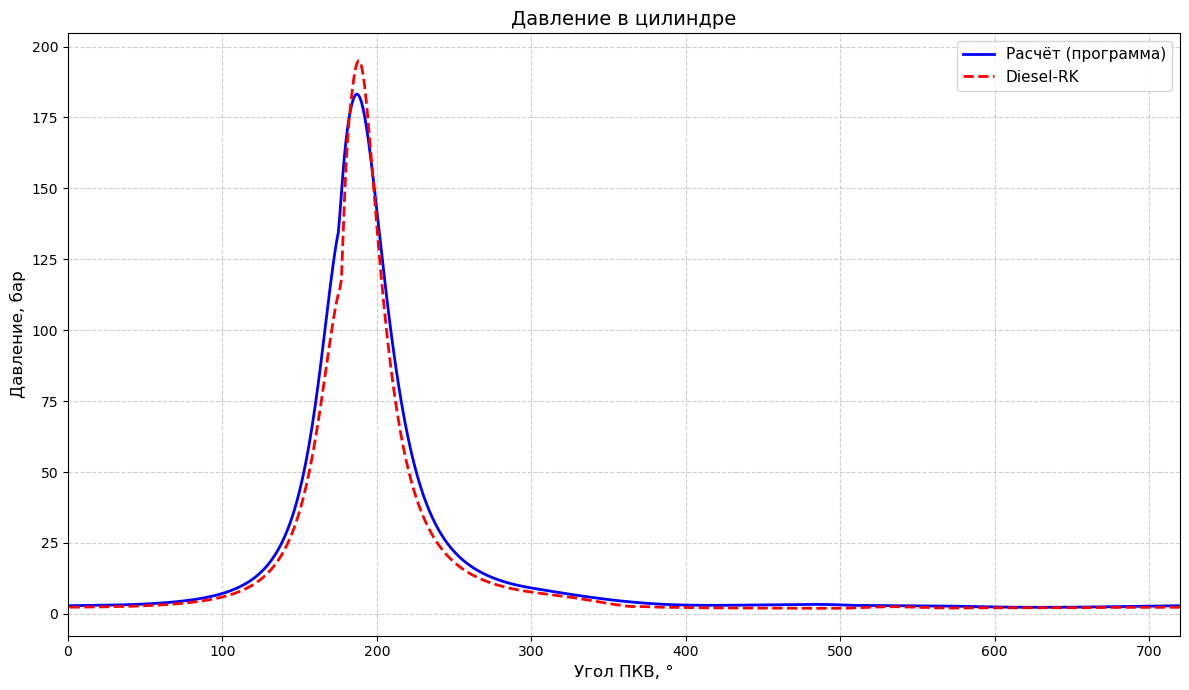

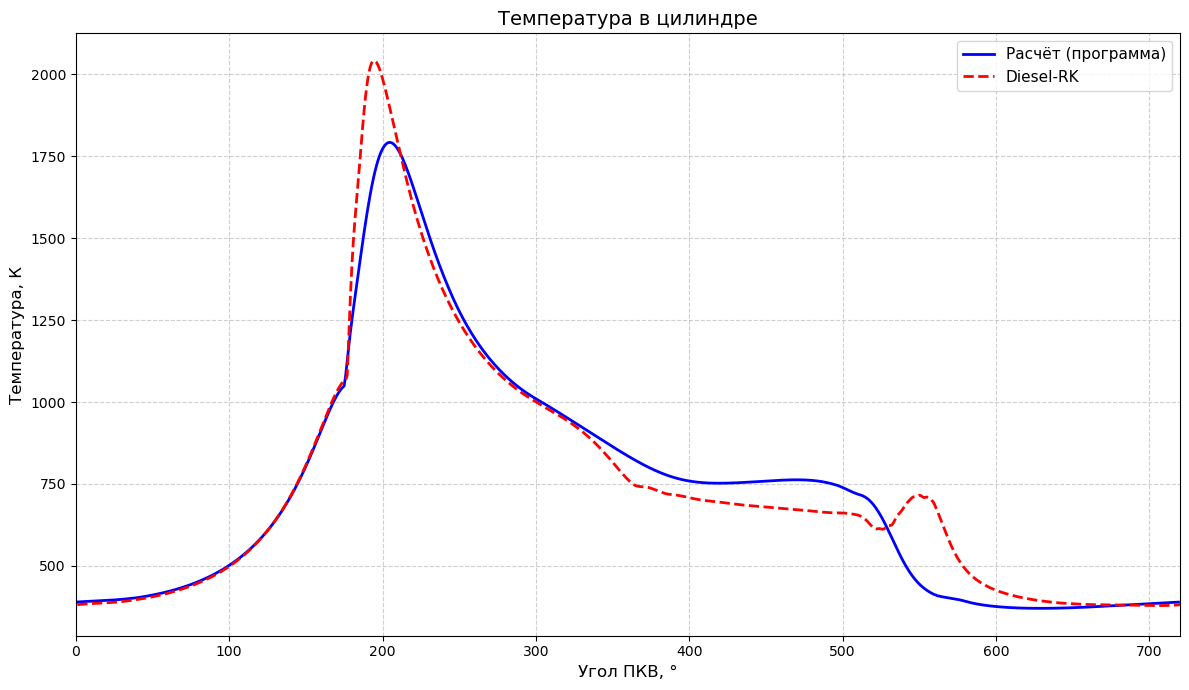

In [540]:
# ------------------- Чтение результатов Diesel-RK для сравнения -------------------
pressure_file = "F:/Kaspersky/HUPC/第八/RK-P.xlsx"
temperature_file = "F:/Kaspersky/HUPC/第八/RK-T.xlsx"

P_1d = P[:, 0] if P.ndim == 2 else P
T_1d = T[:, 0] if T.ndim == 2 else T
angle = np.arange(0, 720)

df_p = pd.read_excel(pressure_file)
angle_sim_p = df_p.iloc[:, 0].values
pressure_sim = df_p.iloc[:, 1].values   # ожидается в Па

df_t = pd.read_excel(temperature_file)
angle_sim_t = df_t.iloc[:, 0].values
temperature_sim = df_t.iloc[:, 1].values

# ---- График давления ----
plt.figure(figsize=(12, 7))
plt.plot(angle, P_1d / 1e5, linewidth=2, label='Расчёт (программа)', color='blue')
plt.plot(angle_sim_p - 180, pressure_sim, '--', linewidth=2, label='Diesel-RK', color='red')
plt.xlabel('Угол ПКВ, °', fontsize=12)
plt.ylabel('Давление, бар', fontsize=12)
plt.title('Давление в цилиндре', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(0, 720)
plt.tight_layout()
plt.show()

# ---- График температуры ----
plt.figure(figsize=(12, 7))
plt.plot(angle, T_1d, linewidth=2, label='Расчёт (программа)', color='blue')
plt.plot(angle_sim_t - 180, temperature_sim, '--', linewidth=2, label='Diesel-RK', color='red')
plt.xlabel('Угол ПКВ, °', fontsize=12)
plt.ylabel('Температура, К', fontsize=12)
plt.title('Температура в цилиндре', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(0, 720)
plt.tight_layout()
plt.show()

In [541]:
# -------- Расчёт давлений за тремя поршневыми кольцами --------
D_cyl = D
n_rpm = n
omega = 2 * np.pi * n_rpm / 60

# Объёмы между кольцами (зазоры + канавки)
h1, c1 = 0.01059, 0.0038
h2, c2 = 0.0045, 0.0026
h3, c3 = 0.06558, 0.0045
b1 = 0.0042
b2 = 0.004
b3 = 0.005

V_land1 = np.pi * D_cyl * b1 * (h1 + c1)
V_land2 = np.pi * D_cyl * b2 * (h2 + c2)
V_land3 = np.pi * D_cyl * b3 * (h3 + c3)

A_gap = 1.04e-6          # площадь кольцевого зазора, м²
mu_gap = 0.8             # коэффициент расхода
Ml = 28.9e-3
R_specific = Rm / Ml
kappa = 1.33
cv = R_specific / (kappa - 1)
cp = kappa * cv
P_crank = 101325.0       # давление в картере, Па
T_crank = 300.0          # температура в картере, К

In [542]:
def mass_flow_rate_signed(P_up, T_up, P_down, T_down, A_eff, mu):
    """Массовый расход через дроссельное отверстие с учётом направления"""
    if P_up == P_down:
        return 0.0
    if P_up > P_down:
        direction = 1
        P_in, P_out, T_in = P_up, P_down, T_up
    else:
        direction = -1
        P_in, P_out, T_in = P_down, P_up, T_down
    rho_in = P_in / (R_specific * T_in)
    beta_crit = (2 / (kappa + 1)) ** (kappa / (kappa - 1))
    beta = P_out / P_in
    if beta <= beta_crit:
        psi = np.sqrt(2*kappa/(kappa-1) * (beta_crit**(2/kappa) - beta_crit**((kappa+1)/kappa)))
    else:
        psi = np.sqrt(2*kappa/(kappa-1) * (beta**(2/kappa) - beta**((kappa+1)/kappa)))
    mdot = mu * A_eff * psi * np.sqrt(P_in * rho_in)
    return direction * mdot

In [543]:
# Инициализация камер
P1_init = P0
P2_init = P0
P3_init = P0
T_init = T0
M1 = P1_init * V_land1 / (R_specific * T_init)
M2 = P2_init * V_land2 / (R_specific * T_init)
M3 = P3_init * V_land3 / (R_specific * T_init)
T1 = T2 = T3 = T_init
P1 = P2 = P3 = P1_init

In [544]:
n_angles = P.shape[0] if P.ndim == 2 else len(P)
P_land1 = np.zeros(n_angles)
P_land2 = np.zeros(n_angles)
P_land3 = np.zeros(n_angles)
T_land1 = np.zeros(n_angles)
T_land2 = np.zeros(n_angles)
T_land3 = np.zeros(n_angles)
mdot4_arr = np.zeros(n_angles)          # расход через третье кольцо (в картер)
blowby_accumulated = np.zeros(n_angles) # накопленная масса прорыва

for cycle in range(2):
    for i in range(n_angles):
        P_cyl = P[i, 0] if P.ndim == 2 else P[i]
        T_cyl = T[i, 0] if T.ndim == 2 else T[i]

        if cycle == 0:
            P1 = P_cyl; P2 = P_cyl; P3 = P_cyl
            T1 = T_cyl; T2 = T_cyl; T3 = T_cyl
            M1 = P1 * V_land1 / (R_specific * T1)
            M2 = P2 * V_land2 / (R_specific * T2)
            M3 = P3 * V_land3 / (R_specific * T3)
            P_land1[i] = P1; P_land2[i] = P2; P_land3[i] = P3
            continue

        mdot1 = mass_flow_rate_signed(P_cyl, T_cyl, P1, T1, A_gap, mu_gap)
        mdot2 = mass_flow_rate_signed(P1, T1, P2, T2, A_gap, mu_gap)
        mdot3 = mass_flow_rate_signed(P2, T2, P3, T3, A_gap, mu_gap)
        mdot4 = mass_flow_rate_signed(P3, T3, P_crank, T_crank, A_gap, mu_gap)

        dt = dFi / omega

        # Камера 1
        dm1 = (mdot1 - mdot2) * dt
        M1_new = max(M1 + dm1, 1e-12)
        U1 = M1 * cv * T1
        U1_new = U1 + (mdot1 * cp * (T_cyl if mdot1 > 0 else T1) -
                       mdot2 * cp * (T1 if mdot2 > 0 else T2)) * dt
        T1_new = U1_new / (M1_new * cv)
        P1_new = M1_new * R_specific * T1_new / V_land1

        # Камера 2
        dm2 = (mdot2 - mdot3) * dt
        M2_new = max(M2 + dm2, 1e-12)
        U2 = M2 * cv * T2
        U2_new = U2 + (mdot2 * cp * (T1 if mdot2 > 0 else T2) -
                       mdot3 * cp * (T2 if mdot3 > 0 else T3)) * dt
        T2_new = U2_new / (M2_new * cv)
        P2_new = M2_new * R_specific * T2_new / V_land2

        # Камера 3
        dm3 = (mdot3 - mdot4) * dt
        M3_new = max(M3 + dm3, 1e-12)
        U3 = M3 * cv * T3
        U3_new = U3 + (mdot3 * cp * (T2 if mdot3 > 0 else T3) -
                       mdot4 * cp * (T3 if mdot4 > 0 else T_crank)) * dt
        T3_new = U3_new / (M3_new * cv)
        P3_new = M3_new * R_specific * T3_new / V_land3

        if cycle == 1:
            mdot4_arr[i] = mdot4
            if i == 0:
                blowby_accumulated[i] = 0.0
            else:
                blowby_accumulated[i] = blowby_accumulated[i-1] + max(mdot4, 0.0) * dt
            P_land1[i] = P1_new
            P_land2[i] = P2_new
            P_land3[i] = P3_new
            T_land1[i] = T1_new
            T_land2[i] = T2_new
            T_land3[i] = T3_new

        M1, T1, P1 = M1_new, T1_new, P1_new
        M2, T2, P2 = M2_new, T2_new, P2_new
        M3, T3, P3 = M3_new, T3_new, P3_new

In [545]:
# Коррекция первого значения
P_land1[0] = P_land1[1]
P_land2[0] = P_land2[1]
P_land3[0] = P_land3[1]

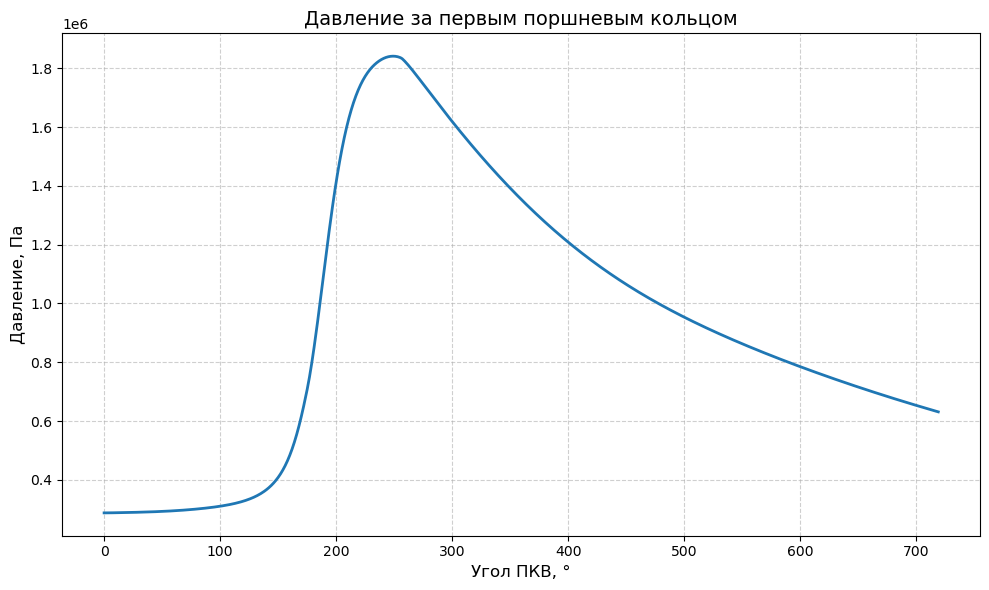

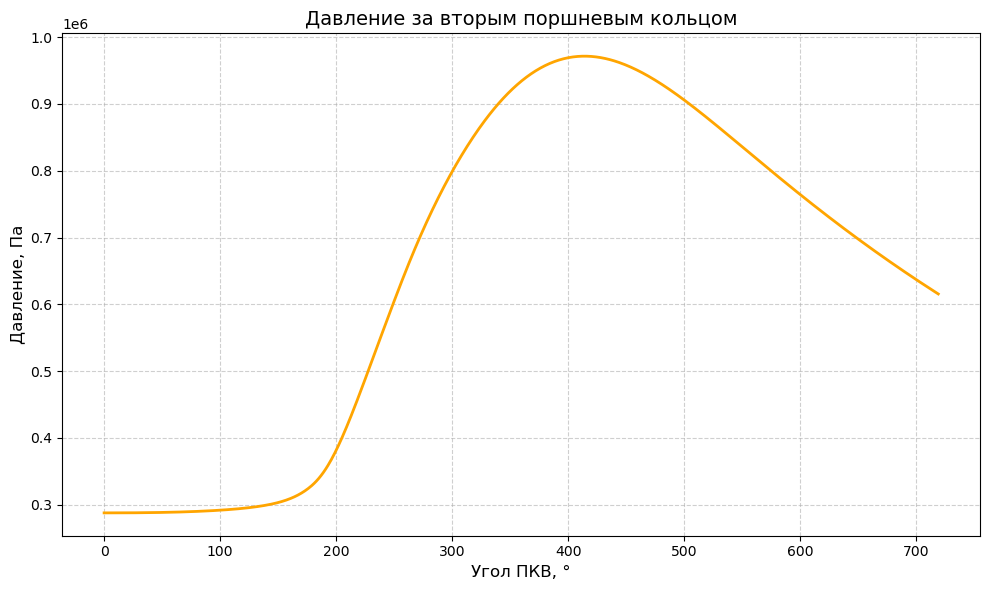

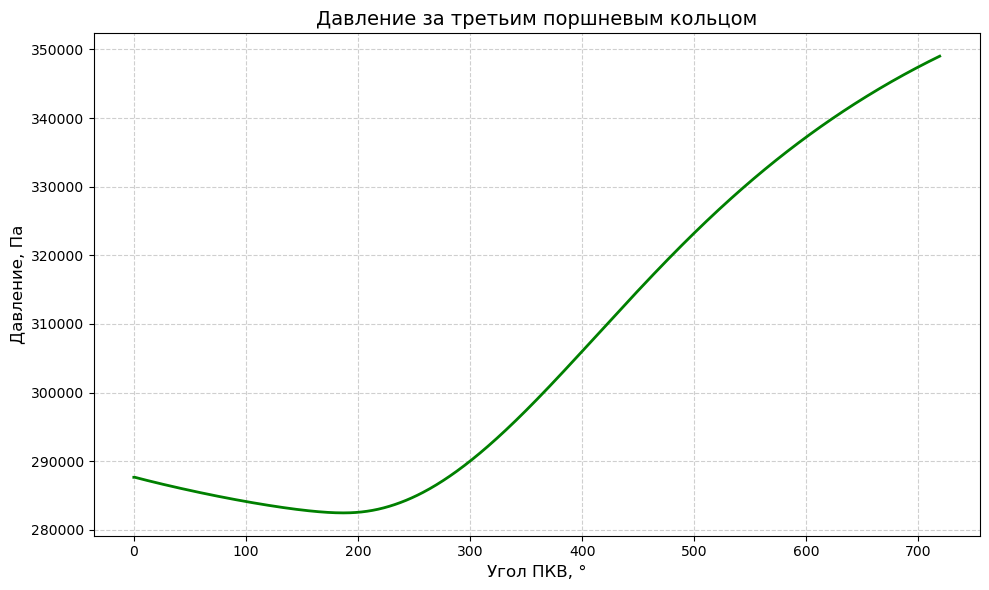

In [546]:
# ---- Графики давлений за кольцами ----
angle_deg = np.arange(n_angles)

plt.figure(figsize=(10,6))
plt.plot(angle_deg, P_land1, linewidth=2)
plt.xlabel('Угол ПКВ, °', fontsize=12)
plt.ylabel('Давление, Па', fontsize=12)
plt.title('Давление за первым поршневым кольцом', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(angle_deg, P_land2, linewidth=2, color='orange')
plt.xlabel('Угол ПКВ, °', fontsize=12)
plt.ylabel('Давление, Па', fontsize=12)
plt.title('Давление за вторым поршневым кольцом', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(angle_deg, P_land3, linewidth=2, color='green')
plt.xlabel('Угол ПКВ, °', fontsize=12)
plt.ylabel('Давление, Па', fontsize=12)
plt.title('Давление за третьим поршневым кольцом', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

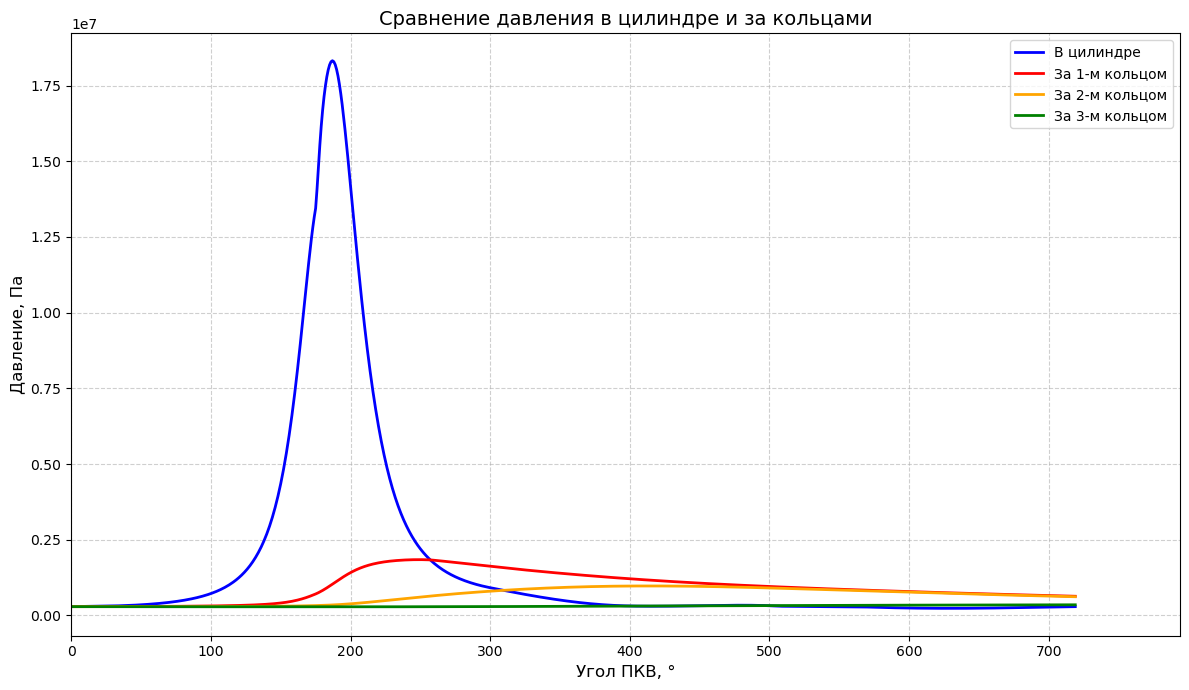

In [547]:
# ---- Сравнительный график всех давлений ----
plt.figure(figsize=(12, 7))
plt.plot(angle_deg, P[:,0] if P.ndim==2 else P, linewidth=2, label='В цилиндре', color='blue')
plt.plot(angle_deg, P_land1, linewidth=2, label='За 1-м кольцом', color='red')
plt.plot(angle_deg, P_land2, linewidth=2, label='За 2-м кольцом', color='orange')
plt.plot(angle_deg, P_land3, linewidth=2, label='За 3-м кольцом', color='green')
plt.xlabel('Угол ПКВ, °', fontsize=12)
plt.ylabel('Давление, Па', fontsize=12)
plt.title('Сравнение давления в цилиндре и за кольцами', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)
plt.xlim(0, Fi_zvk + N)
plt.tight_layout()
plt.show()

In [548]:
# ---- Расчёт прорыва газов (blow-by) ----
dt = dFi / omega
total_blowby = np.trapz(np.maximum(mdot4_arr, 0.0), dx=dt)
molar_IVC = M['Mixture'][Fi_zvk, 0]   # моль в момент закрытия впуска
m_air_IVC = molar_IVC * 28.9e-3       # кг
print(f"Масса воздуха в цилиндре при закрытии впуска = {m_air_IVC*1000:.3f} г")

blowby_percent = total_blowby / m_air_IVC * 100.0
print("\n========== Результаты расчёта прорыва газов ==========")
print(f"Масса прорыва за цикл = {total_blowby*1000:.3f} г")
print(f"Масса воздуха при закрытии впуска = {m_air_IVC*1000:.3f} г")
print(f"Доля прорыва = {blowby_percent:.2f} %")
if blowby_percent <= 7.0:
    print("Результат в допустимых пределах (≤7%), герметичность хорошая.")
else:
    print("Результат повышен, рекомендуется оптимизировать зазоры колец.")

Масса воздуха в цилиндре при закрытии впуска = 3.029 г

========== Результаты расчёта прорыва газов ==========
Масса прорыва за цикл = 0.026 г
Масса воздуха при закрытии впуска = 3.029 г
Доля прорыва = 0.86 %
Результат в допустимых пределах (≤7%), герметичность хорошая.


In [549]:
# Средние температуры газов в закольцевых объёмах
T1_mean = np.mean(T_land1)
T2_mean = np.mean(T_land2)
T3_mean = np.mean(T_land3)
print("\n========== Средние температуры газов в закольцевых объёмах ==========")
print(f"За первым кольцом (V_land1): T_ср = {T1_mean:.2f} K")
print(f"За вторым кольцом (V_land2): T_ср = {T2_mean:.2f} K")
print(f"За третьим кольцом (V_land3): T_ср = {T3_mean:.2f} K")
print("Примечание: это температуры газов, а не самих колец.")


========== Средние температуры газов в закольцевых объёмах ==========
За первым кольцом (V_land1): T_ср = 851.52 K
За вторым кольцом (V_land2): T_ср = 693.15 K
За третьим кольцом (V_land3): T_ср = 412.04 K
Примечание: это температуры газов, а не самих колец.


In [550]:
# ---- Осевые газовые силы на кольцах ----
P_cyl = P[:, 0] if P.ndim == 2 else P
A_axial1 = np.pi * D_cyl * b1
A_axial2 = np.pi * D_cyl * b2
A_axial3 = np.pi * D_cyl * b3

F_gas_axial1 = (P_cyl - P_land1) * A_axial1
F_gas_axial2 = (P_land1 - P_land2) * A_axial2
F_gas_axial3 = (P_land2 - P_land3) * A_axial3

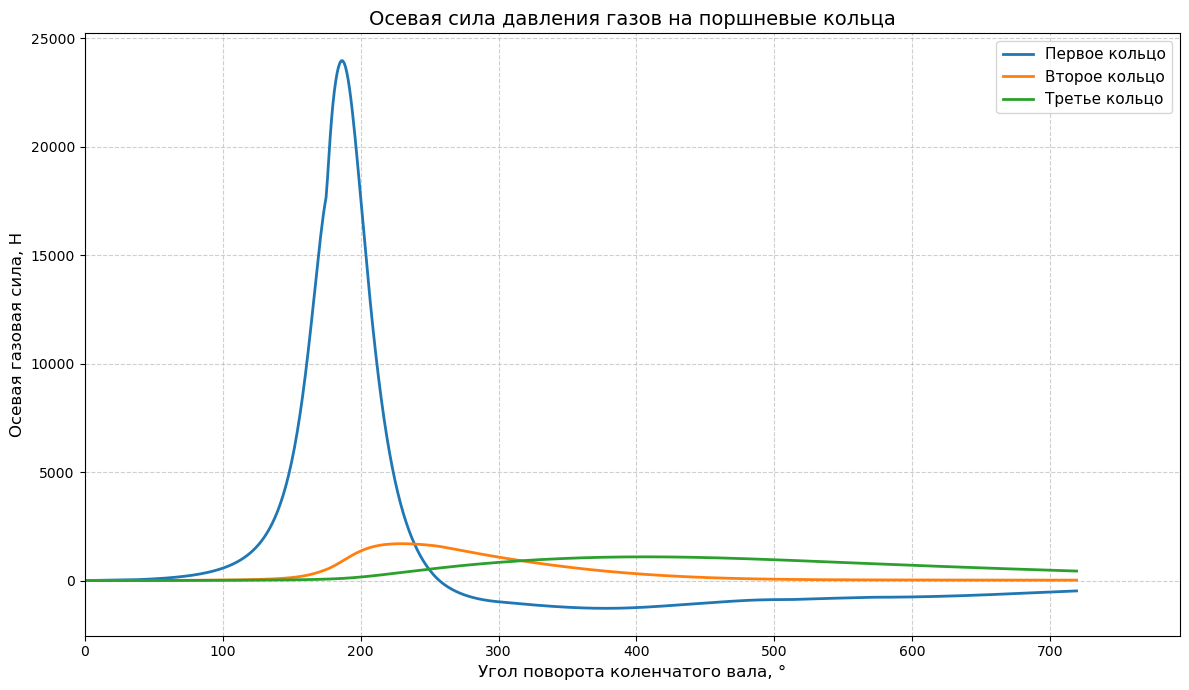

In [551]:
plt.figure(figsize=(12, 7))
plt.plot(angle_deg, F_gas_axial1, linewidth=2, label='Первое кольцо')
plt.plot(angle_deg, F_gas_axial2, linewidth=2, label='Второе кольцо')
plt.plot(angle_deg, F_gas_axial3, linewidth=2, label='Третье кольцо')
plt.xlabel('Угол поворота коленчатого вала, °', fontsize=12)
plt.ylabel('Осевая газовая сила, Н', fontsize=12)
plt.title('Осевая сила давления газов на поршневые кольца', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(0, Fi_zvk + N)
plt.tight_layout()
plt.show()

In [552]:
# ---- Инерционные и фрикционные силы ----
m_ring1, m_ring2, m_ring3 = 0.0273, 0.0241, 0.0480
A_radial1 = np.pi * D_cyl * c1
A_radial2 = np.pi * D_cyl * c2
A_radial3 = np.pi * D_cyl * c3
F_elastic1, F_elastic2, F_elastic3 = 30.0, 25.0, 20.0
mu_groove = 0.15

R_crank = S / 2.0
omega = 2 * np.pi * n / 60.0
a_piston = np.zeros(n_angles)
F_inertia1 = np.zeros(n_angles)
F_inertia2 = np.zeros(n_angles)
F_inertia3 = np.zeros(n_angles)
F_gas_radial1 = np.zeros(n_angles)
F_gas_radial2 = np.zeros(n_angles)
F_gas_radial3 = np.zeros(n_angles)
F_friction1 = np.zeros(n_angles)
F_friction2 = np.zeros(n_angles)
F_friction3 = np.zeros(n_angles)

for i in range(n_angles):
    phi_rad = np.deg2rad(angle_deg[i])
    a_piston[i] = R_crank * omega**2 * (np.cos(phi_rad) + lamb * np.cos(2*phi_rad))
    F_inertia1[i] = -m_ring1 * a_piston[i]
    F_inertia2[i] = -m_ring2 * a_piston[i]
    F_inertia3[i] = -m_ring3 * a_piston[i]

    p_back1 = max(P_cyl[i], P_land1[i])
    p_back2 = max(P_land1[i], P_land2[i])
    p_back3 = max(P_land2[i], P_land3[i])
    F_gas_radial1[i] = p_back1 * A_radial1
    F_gas_radial2[i] = p_back2 * A_radial2
    F_gas_radial3[i] = p_back3 * A_radial3

    F_friction1[i] = mu_groove * (F_gas_radial1[i] + F_elastic1)
    F_friction2[i] = mu_groove * (F_gas_radial2[i] + F_elastic2)
    F_friction3[i] = mu_groove * (F_gas_radial3[i] + F_elastic3)

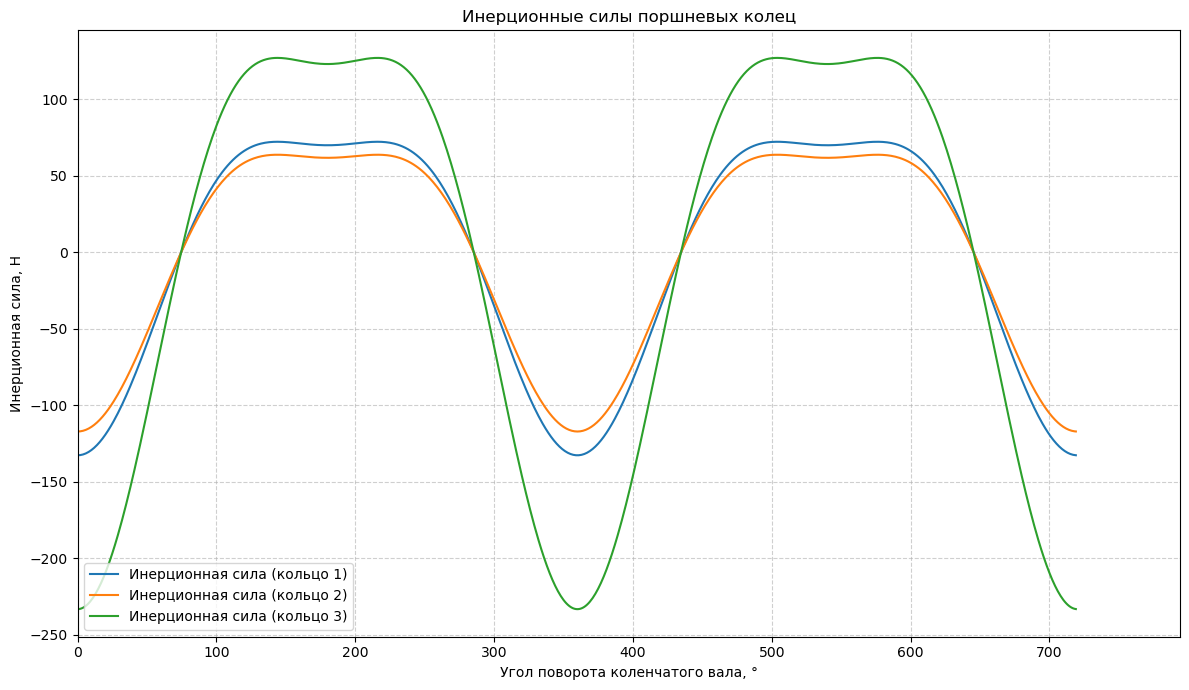

In [553]:
# ---- График инерционных сил ----
plt.figure(figsize=(12, 7))
plt.plot(angle_deg, F_inertia1, label='Инерционная сила (кольцо 1)')
plt.plot(angle_deg, F_inertia2, label='Инерционная сила (кольцо 2)')
plt.plot(angle_deg, F_inertia3, label='Инерционная сила (кольцо 3)')
plt.xlabel('Угол поворота коленчатого вала, °')
plt.ylabel('Инерционная сила, Н')
plt.title('Инерционные силы поршневых колец')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(0, Fi_zvk + N)
plt.tight_layout()
plt.show()

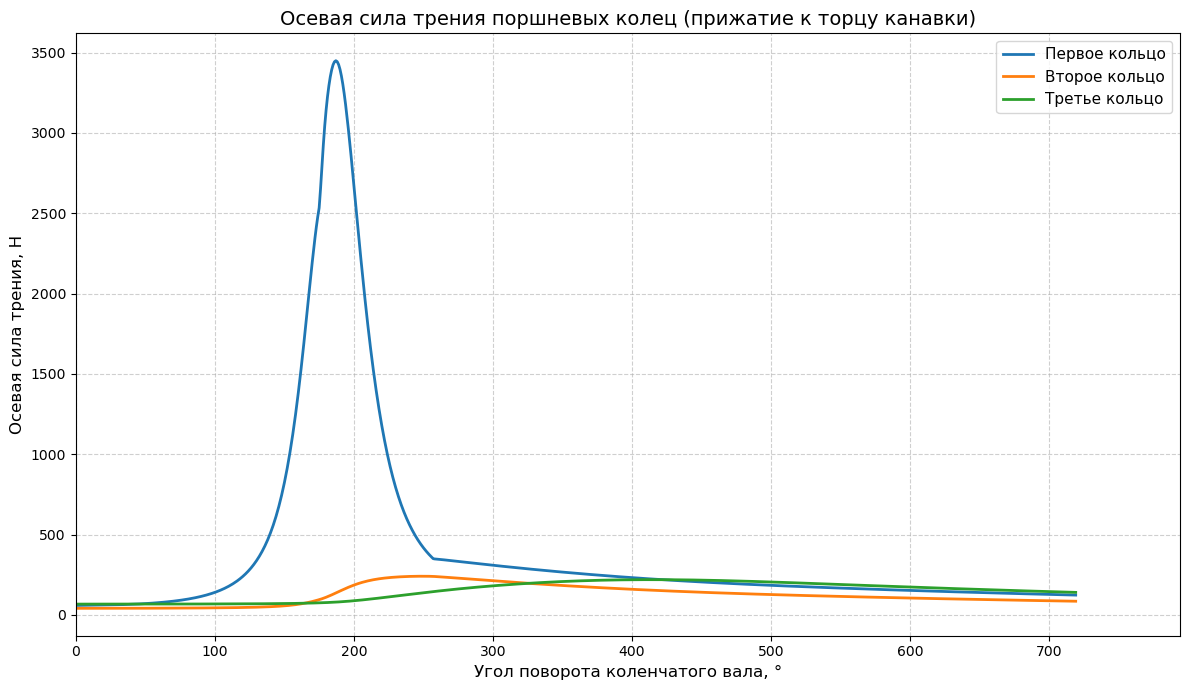

In [554]:
# ---- График сил трения ----
plt.figure(figsize=(12, 7))
plt.plot(angle_deg, F_friction1, linewidth=2, label='Первое кольцо')
plt.plot(angle_deg, F_friction2, linewidth=2, label='Второе кольцо')
plt.plot(angle_deg, F_friction3, linewidth=2, label='Третье кольцо')
plt.xlabel('Угол поворота коленчатого вала, °', fontsize=12)
plt.ylabel('Осевая сила трения, Н', fontsize=12)
plt.title('Осевая сила трения поршневых колец (прижатие к торцу канавки)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(0, Fi_zvk + N)
plt.tight_layout()
plt.show()

In [555]:
# ---- Скорость поршня и знак трения ----
v_piston = np.zeros(n_angles)
for i in range(n_angles):
    phi_rad = np.deg2rad(angle_deg[i])
    v_piston[i] = R_crank * omega * (np.sin(phi_rad) + (lamb/2.0) * np.sin(2*phi_rad))

F_fric_signed1 = np.zeros(n_angles)
F_fric_signed2 = np.zeros(n_angles)
F_fric_signed3 = np.zeros(n_angles)

for i in range(n_angles):
    sign = -1.0 if v_piston[i] >= 0 else 1.0
    F_fric_signed1[i] = sign * F_friction1[i]
    F_fric_signed2[i] = sign * F_friction2[i]
    F_fric_signed3[i] = sign * F_friction3[i]

In [556]:
# Суммарная результирующая осевая сила
F_total1 = F_gas_axial1 - F_inertia1 + F_fric_signed1
F_total2 = F_gas_axial2 - F_inertia2 + F_fric_signed2
F_total3 = F_gas_axial3 - F_inertia3 + F_fric_signed3

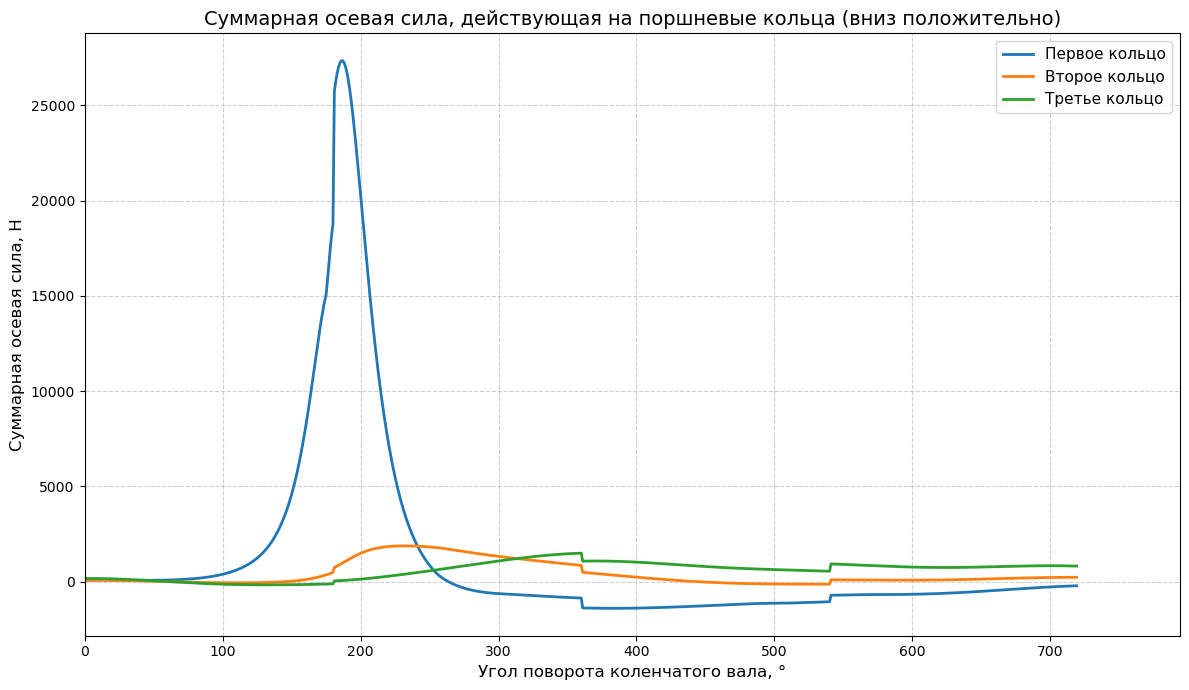

In [557]:
plt.figure(figsize=(12, 7))
plt.plot(angle_deg, F_total1, linewidth=2, label='Первое кольцо')
plt.plot(angle_deg, F_total2, linewidth=2, label='Второе кольцо')
plt.plot(angle_deg, F_total3, linewidth=2, label='Третье кольцо')
plt.xlabel('Угол поворота коленчатого вала, °', fontsize=12)
plt.ylabel('Суммарная осевая сила, Н', fontsize=12)
plt.title('Суммарная осевая сила, действующая на поршневые кольца (вниз положительно)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(0, Fi_zvk + N)
plt.tight_layout()
plt.show()

In [558]:
# ========== Анализ перекладки колец ==========
def find_intervals(condition):
    """Находит непрерывные интервалы, где условие True"""
    intervals = []
    in_int = False
    start = None
    n = len(condition)
    for i in range(n):
        if condition[i] and not in_int:
            start = i
            in_int = True
        elif not condition[i] and in_int:
            intervals.append((angle_deg[start], angle_deg[i-1]))
            in_int = False
    if in_int:
        intervals.append((angle_deg[start], angle_deg[n-1]))
    return intervals

In [559]:
#  Рассчитайте отношение времени контакта верхней и нижней сторон трех колец.
rings = ['Первое поршневое кольцо', 'Второе поршневое кольцо', 'Третье поршневое кольцо']
forces = [F_total1, F_total2, F_total3]

phi_down = []   
phi_up   = []   

for idx, (name, F_tot) in enumerate(zip(rings, forces)):
    cond_down = F_tot > 0   # 贴下侧
    cond_up   = F_tot < 0   # 贴上侧
    
    n_total = len(F_tot)
    n_down = np.sum(cond_down)
    n_up   = np.sum(cond_up)
    ratio_down = n_down / n_total
    ratio_up   = n_up   / n_total
    
    phi_down.append(ratio_down)
    phi_up.append(ratio_up)
    
    down_intervals = find_intervals(cond_down)
    up_intervals = find_intervals(cond_up)
    
    print(f"{name} Диапазон углов, наиболее близких к нижней стороне (направление в сторону картера):")
    if down_intervals:
        for (s, e) in down_intervals:
            print(f"  {s:.1f}° ~ {e:.1f}°")
    else:
        print("  Нет")
    print(f"{name} Диапазон углов для верхней стороны (направление камеры сгорания):")
    if up_intervals:
        for (s, e) in up_intervals:
            print(f"  {s:.1f}° ~ {e:.1f}°")
    else:
        print("  Нет")
    print(f"--> Соотношение времени контакта: нижняя сторона = {ratio_down:.4f}, верхняя сторона = {ratio_up:.4f}\n")

phi_down1, phi_down2, phi_down3 = phi_down
phi_up1,   phi_up2,   phi_up3   = phi_up


Первое поршневое кольцо Диапазон углов, наиболее близких к нижней стороне (направление в сторону картера):
  0.0° ~ 263.0°
Первое поршневое кольцо Диапазон углов для верхней стороны (направление камеры сгорания):
  264.0° ~ 719.0°
--> Соотношение времени контакта: нижняя сторона = 0.3667, верхняя сторона = 0.6333

Второе поршневое кольцо Диапазон углов, наиболее близких к нижней стороне (направление в сторону картера):
  0.0° ~ 58.0°
  147.0° ~ 442.0°
  541.0° ~ 719.0°
Второе поршневое кольцо Диапазон углов для верхней стороны (направление камеры сгорания):
  59.0° ~ 146.0°
  443.0° ~ 540.0°
--> Соотношение времени контакта: нижняя сторона = 0.7417, верхняя сторона = 0.2583

Третье поршневое кольцо Диапазон углов, наиболее близких к нижней стороне (направление в сторону картера):
  0.0° ~ 59.0°
  181.0° ~ 719.0°
Третье поршневое кольцо Диапазон углов для верхней стороны (направление камеры сгорания):
  60.0° ~ 180.0°
--> Соотношение времени контакта: нижняя сторона = 0.8319, верхняя ст

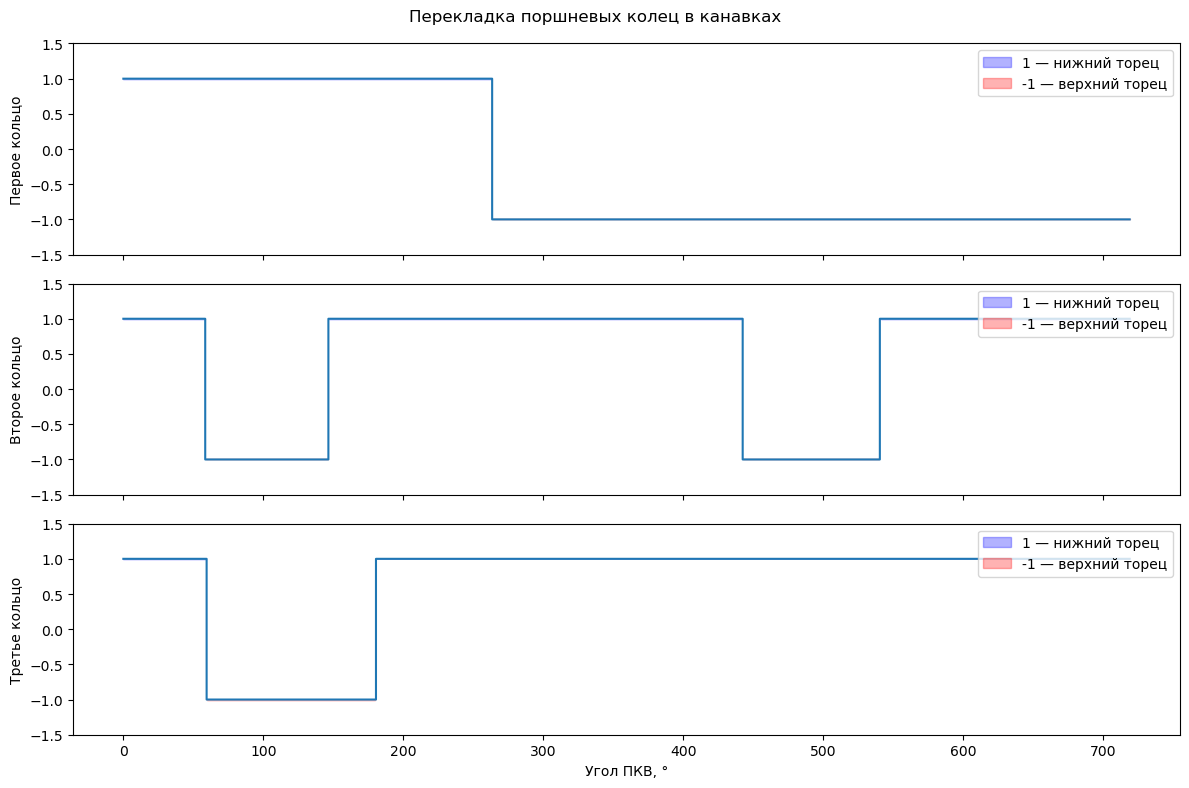

In [560]:
# ---- График перекладки ----
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for idx, (F, title) in enumerate(zip([F_total1, F_total2, F_total3],
                                     ['Первое кольцо', 'Второе кольцо', 'Третье кольцо'])):
    contact = np.where(F > 0, 1, -1)
    ax[idx].step(angle_deg, contact, where='mid', linewidth=1.5)
    ax[idx].fill_between(angle_deg, 1, contact, where=(contact>0), color='blue', alpha=0.3, label='1 — нижний торец')
    ax[idx].fill_between(angle_deg, -1, contact, where=(contact<0), color='red', alpha=0.3, label='-1 — верхний торец')
    ax[idx].set_ylim(-1.5, 1.5)
    ax[idx].set_ylabel(title)
    ax[idx].legend(loc='upper right')
ax[-1].set_xlabel('Угол ПКВ, °')
fig.suptitle('Перекладка поршневых колец в канавках')
plt.tight_layout()
plt.show()

In [561]:
#Рассчитайте коэффициент теплопередачи на торцевой поверхности кольца
# Параметры материала
lambda_steel = 45.0          # Теплопроводность стали, Вт/(м·К)
lambda_oil   = 0.145         # Теплопроводность моторного масла, Вт/(м·К)
E_steel      = 2.1e11        # Модуль упругости стали, Па
nu           = 0.3
E_reduced = E_steel / (2 * (1 - nu**2))   # Эквивалентный модуль упругости, Па

# Параметры морфологии поверхности
B_Pi = 0.8                  # Безразмерный коэффициент, обычно 0,6–1,0
hmax1 = 2.0e-6               # Максимальная высота неровности первой поверхности, м
hmax2 = 2.0e-6               # Максимальная высота неровности второй поверхности, м
m_param = 0.5                # Коэффициент заполнения контура
d_param = 0.3                # Пиковый коэффициент влияния

# Зазор не заделан должным образом
delta_gap = 80e-6           # Осевой зазор, м

A_end1 = np.pi * D_cyl * c1
A_end2 = np.pi * D_cyl * c2
A_end3 = np.pi * D_cyl * c3

In [562]:
def alpha_contact(p_contact):
    p_kgf_cm2 = p_contact 
    E_kgf_cm2 = E_reduced 

    factor = (p_kgf_cm2 / E_kgf_cm2) * B_Pi
    term1 = 2.12 * lambda_steel * 1e4 * (np.abs(factor) ** 0.8)
    term2 = 12500.0
    
    return term1 + term2

In [563]:
#Функция коэффициента теплопередачи для поверхностей, неплотно прикрепленных к торцевой поверхности
def alpha_non_contact():
    
    return 350

In [564]:
alpha_up1 = np.zeros(n_angles)
alpha_up2 = np.zeros(n_angles)
alpha_up3 = np.zeros(n_angles)

alpha_down1 = np.zeros(n_angles)
alpha_down2 = np.zeros(n_angles)
alpha_down3 = np.zeros(n_angles)

In [565]:
#Рассчитайте коэффициенты теплопередачи на торцевых поверхностях трех колец.
for i in range(n_angles):
    if F_total1[i] >= 0:
        p_down1 = np.abs(F_total1[i]) / A_end1
        alpha_down1[i] = alpha_contact(p_down1)
        alpha_up1[i] = alpha_non_contact()
    else:
        p_up1 = np.abs(F_total1[i]) / A_end1
        alpha_up1[i] = alpha_contact(p_up1)
        alpha_down1[i] = alpha_non_contact()

    if F_total2[i] >= 0:
        p_down2 = np.abs(F_total2[i]) / A_end2
        alpha_down2[i] = alpha_contact(p_down2)
        alpha_up2[i] = alpha_non_contact()
    else:
        p_up2 = np.abs(F_total2[i]) / A_end2
        alpha_up2[i] = alpha_contact(p_up2)
        alpha_down2[i] = alpha_non_contact()

    if F_total3[i] >= 0:
        p_down3 = np.abs(F_total3[i]) / A_end3
        alpha_down3[i] = alpha_contact(p_down3)
        alpha_up3[i] = alpha_non_contact()
    else:
        p_up3 = np.abs(F_total3[i]) / A_end3
        alpha_up3[i] = alpha_contact(p_up3)
        alpha_down3[i] = alpha_non_contact()

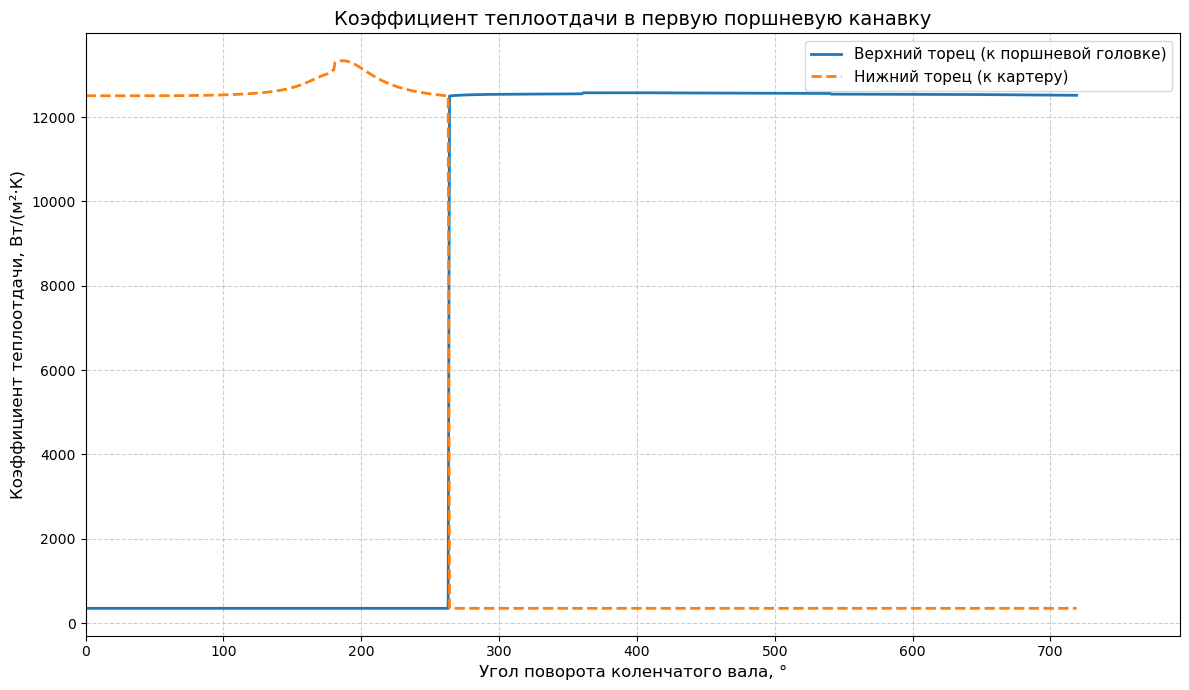

In [566]:
# Графики альфа для каждой канавки 
plt.figure(figsize=(12, 7))
plt.plot(angle_deg, alpha_up1, label='Верхний торец (к поршневой головке)', linewidth=2)
plt.plot(angle_deg, alpha_down1, label='Нижний торец (к картеру)', linewidth=2, linestyle='--')
plt.xlabel('Угол поворота коленчатого вала, °', fontsize=12)
plt.ylabel('Коэффициент теплоотдачи, Вт/(м²·К)', fontsize=12)
plt.title('Коэффициент теплоотдачи в первую поршневую канавку', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(0, Fi_zvk + N)
plt.tight_layout()
plt.show()

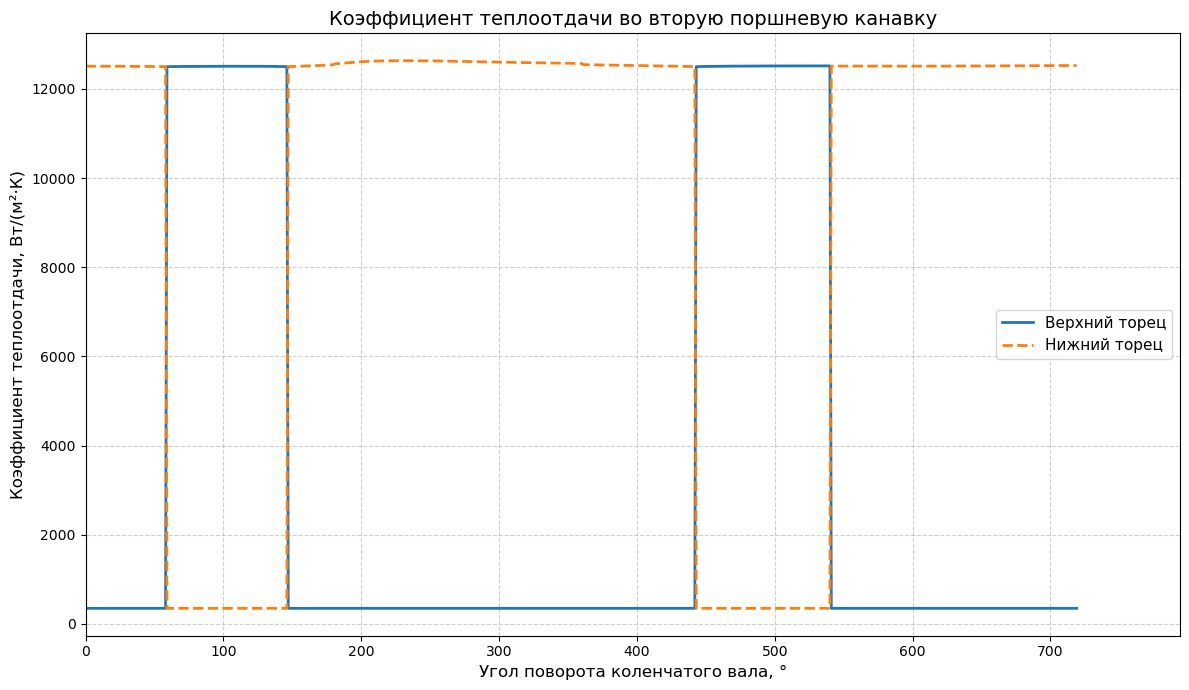

In [567]:
plt.figure(figsize=(12, 7))
plt.plot(angle_deg, alpha_up2, label='Верхний торец', linewidth=2)
plt.plot(angle_deg, alpha_down2, label='Нижний торец', linewidth=2, linestyle='--')
plt.xlabel('Угол поворота коленчатого вала, °', fontsize=12)
plt.ylabel('Коэффициент теплоотдачи, Вт/(м²·К)', fontsize=12)
plt.title('Коэффициент теплоотдачи во вторую поршневую канавку', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(0, Fi_zvk + N)
plt.tight_layout()
plt.show()

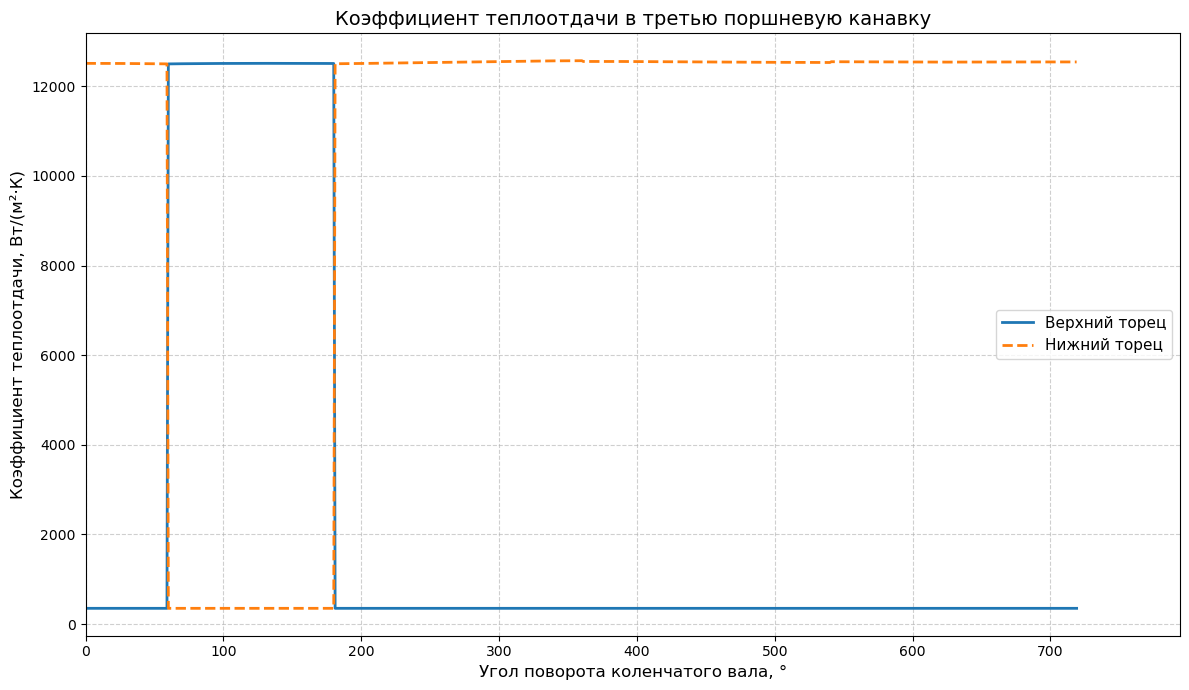

In [568]:
plt.figure(figsize=(12, 7))
plt.plot(angle_deg, alpha_up3, label='Верхний торец', linewidth=2)
plt.plot(angle_deg, alpha_down3, label='Нижний торец', linewidth=2, linestyle='--')
plt.xlabel('Угол поворота коленчатого вала, °', fontsize=12)
plt.ylabel('Коэффициент теплоотдачи, Вт/(м²·К)', fontsize=12)
plt.title('Коэффициент теплоотдачи в третью поршневую канавку', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(0, Fi_zvk + N)
plt.tight_layout()
plt.show()

In [569]:
# ---- Средние значения ----
alpha_up1_mean = np.mean(alpha_up1)
alpha_down1_mean = np.mean(alpha_down1)
alpha_up2_mean = np.mean(alpha_up2)
alpha_down2_mean = np.mean(alpha_down2)
alpha_up3_mean = np.mean(alpha_up3)
alpha_down3_mean = np.mean(alpha_down3)

print("========== Средние коэффициенты теплоотдачи ==========")
print(f"Первое кольцо:  верхний торец = {alpha_up1_mean:.2f} Вт/(м²·К)")
print(f"Первое кольцо:  нижний торец = {alpha_down1_mean:.2f} Вт/(м²·К)")
print(f"Второе кольцо:  верхний торец = {alpha_up2_mean:.2f} Вт/(м²·К)")
print(f"Второе кольцо:  нижний торец = {alpha_down2_mean:.2f} Вт/(м²·К)")
print(f"Третье кольцо:  верхний торец = {alpha_up3_mean:.2f} Вт/(м²·К)")
print(f"Третье кольцо:  нижний торец = {alpha_down3_mean:.2f} Вт/(м²·К)")
print("========================================================")

========== Средние коэффициенты теплоотдачи ==========
Первое кольцо:  верхний торец = 8077.17 Вт/(м²·К)
Первое кольцо:  нижний торец = 4869.98 Вт/(м²·К)
Второе кольцо:  верхний торец = 3491.26 Вт/(м²·К)
Второе кольцо:  нижний торец = 9395.68 Вт/(м²·К)
Третье кольцо:  верхний торец = 2393.55 Вт/(м²·К)
Третье кольцо:  нижний торец = 10490.75 Вт/(м²·К)


In [570]:
# Расчёт толщины масляной плёнки и теплоотдачи кольцо-гильза (Рейнольдс)

import numpy as np

b_width = [c1, c2, c3]

# 确保使用正确的数组数据（与前面计算结果一致）
P_cyl = P.ravel().copy()          # 缸内压力 (Pa)
T_cyl = T.ravel().copy()          # 缸内温度 (K)
n_angles = len(P_cyl)             # 角度点数

In [571]:
"""Динамическая вязкость масла, Па·с"""
def oil_viscosity(T):
    T_ref = 373.0
    mu_ref = 0.01    
    beta = 0.03      
    return mu_ref * np.exp(-beta * (T - T_ref))

In [572]:
def ring_profile(x, b, delta):
    """Параболический профиль кольца: h(x)=delta*(1-(x/b)^2)"""
    return delta * (1 - x / b)

In [573]:
delta_profiles = [30e-6, 25e-6, 25e-6]

Nx = 21
x_vals_list = []
profiles = []
profiles_rev = []

for k, b in enumerate(b_width):
    xb = np.linspace(0, b, Nx)
    prof_normal = ring_profile(xb, b, delta_profiles[k])
    profiles.append(prof_normal)
    profiles_rev.append(prof_normal[::-1])   

In [574]:
def solve_reynolds_steady(h_total, U, mu, p_in, p_out, dx):
    """Стационарное уравнение Рейнольдса с кавитацией (Christopherson)"""
    U_abs = abs(U)
    N = len(h_total)
    M = np.zeros((N, N))
    bvec = np.zeros(N)

    for i in range(1, N-1):
        hi = h_total[i]
        hi_m1 = h_total[i-1]
        hi_p1 = h_total[i+1]
        M[i, i-1] = hi_m1**3 + 4*hi**3 - hi_p1**3
        M[i, i]   = -8 * hi**3
        M[i, i+1] = -hi_m1**3 + 4*hi**3 + hi_p1**3
        bvec[i] = 12 * dx * mu * U_abs * (hi_p1 - hi_m1)

    M[0, 0] = 1.0; bvec[0] = p_in
    M[N-1, N-1] = 1.0; bvec[N-1] = p_out

    p = np.linalg.solve(M, bvec)
    for _ in range(10):
        for i in range(N-2, 0, -1):
            if p[i] < 0.0:
                p[i] = 0.0
                M[i, :] = 0.0
                M[i, i] = 1.0
                bvec[i] = 0.0
        p = np.linalg.solve(M, bvec)
    p[p < 0] = 0.0
    F_per_unit = np.trapz(p, dx=dx)
    return p, F_per_unit

In [575]:
def reynolds_force(h_t, profile, x_vals, U, mu, p_in, p_out, dx):
    h_total = profile + h_t
    _, F_per_unit = solve_reynolds_steady(h_total, U, mu, p_in, p_out, dx)
    return F_per_unit

In [576]:
def find_equilibrium_h(profile, x_vals, U, mu, p_in, p_out, p_back, elastic_force):
    h_min_limit = 0.5e-6         
    U_abs = abs(U)
    
    if U_abs < 0.01:
        return h_min_limit

    dx = x_vals[1] - x_vals[0]
    A_radial = (x_vals[-1] - x_vals[0]) * np.pi * D_cyl
    F_target = p_back * A_radial + elastic_force

    F_limit = reynolds_force(h_min_limit, profile, x_vals, U_abs, mu, p_in, p_out, dx) * np.pi * D_cyl
    if F_limit <= F_target:
        return h_min_limit      

    h_low = h_min_limit
    h_high = 500e-6
    F_high = reynolds_force(h_high, profile, x_vals, U_abs, mu, p_in, p_out, dx) * np.pi * D_cyl
    if F_high >= F_target:
        return h_high          

    for _ in range(30):
        h_mid = (h_low + h_high) / 2
        F_mid = reynolds_force(h_mid, profile, x_vals, U_abs, mu, p_in, p_out, dx) * np.pi * D_cyl
        if F_mid > F_target:
            h_low = h_mid
        else:
            h_high = h_mid
    return (h_low + h_high) / 2

In [577]:
lambda_oil = 0.145

b_width = [c1, c2, c3]           
ring_mass   = [m_ring1, m_ring2, m_ring3]       
F_elastic   = [F_elastic1, F_elastic2, F_elastic3]  

Nx = 21
x_vals_list = []
profiles = []
profiles_rev = []          

for k, b in enumerate(b_width):
    xb = np.linspace(0, b, Nx)
    x_vals_list.append(xb)
    prof_normal = ring_profile(xb, b, delta_profiles[k])
    profiles.append(prof_normal)
    profiles_rev.append(prof_normal[::-1])   

h_t  = [2e-6, 2e-6, 2e-6]
V_r  = [0.0, 0.0, 0.0]

alpha_ring = [np.zeros(n_angles) for _ in range(3)]
h_mean_ring = [np.zeros(n_angles) for _ in range(3)]
h_min_ring  = [np.zeros(n_angles) for _ in range(3)]

dFi_deg = 0.1               
dFi_rad = np.deg2rad(dFi_deg)
omega_rad = 2 * np.pi * n / 60.0

In [578]:
Tw_liner = 410.0
T_ring_zone = [Tw_liner + 40, Tw_liner + 20, Tw_liner ]

for i in range(n_angles):
    U = v_piston[i]
    p_land = [P_land1[i], P_land2[i], P_land3[i]]
    p_cyl_i = P_cyl[i]

    for k in range(3):
        T_land_est = T_ring_zone[k]
        mu = oil_viscosity(T_land_est)

        if k == 0:
            p_high = max(p_cyl_i, p_land[0])
            p_low  = min(p_cyl_i, p_land[0])
            p_back = p_high
            if p_cyl_i >= p_land[0]:
                p_in = p_cyl_i
                p_out = p_land[0]
                profile_used = profiles[k]      # 正常轮廓（高压在 x=0）
            else:
                p_in = p_land[0]
                p_out = p_cyl_i
                profile_used = profiles_rev[k]  # 反向轮廓（高压在 x=b）
        elif k == 1:
            p_high = max(p_land[0], p_land[1])
            p_low  = min(p_land[0], p_land[1])
            p_back = p_high
            if p_land[0] >= p_land[1]:
                p_in = p_land[0]
                p_out = p_land[1]
                profile_used = profiles[k]
            else:
                p_in = p_land[1]
                p_out = p_land[0]
                profile_used = profiles_rev[k]
        else:  # k == 2
            p_high = max(p_land[1], p_land[2])
            p_low  = min(p_land[1], p_land[2])
            p_back = p_high
            if p_land[1] >= p_land[2]:
                p_in = p_land[1]
                p_out = p_land[2]
                profile_used = profiles[k]
            else:
                p_in = p_land[2]
                p_out = p_land[1]
                profile_used = profiles_rev[k]

        h_eq = find_equilibrium_h(profiles[k], x_vals_list[k], U, mu,
                                  p_in, p_out, p_back, F_elastic[k])
        h_total = profiles[k] + h_eq
        h_min_ring[k][i]  = np.min(h_total)
        h_mean_ring[k][i] = np.mean(h_total)
        alpha_ring[k][i]  = lambda_oil / h_mean_ring[k][i]

Характерный угол: 187.0 ° (максимум давления в цилиндре)


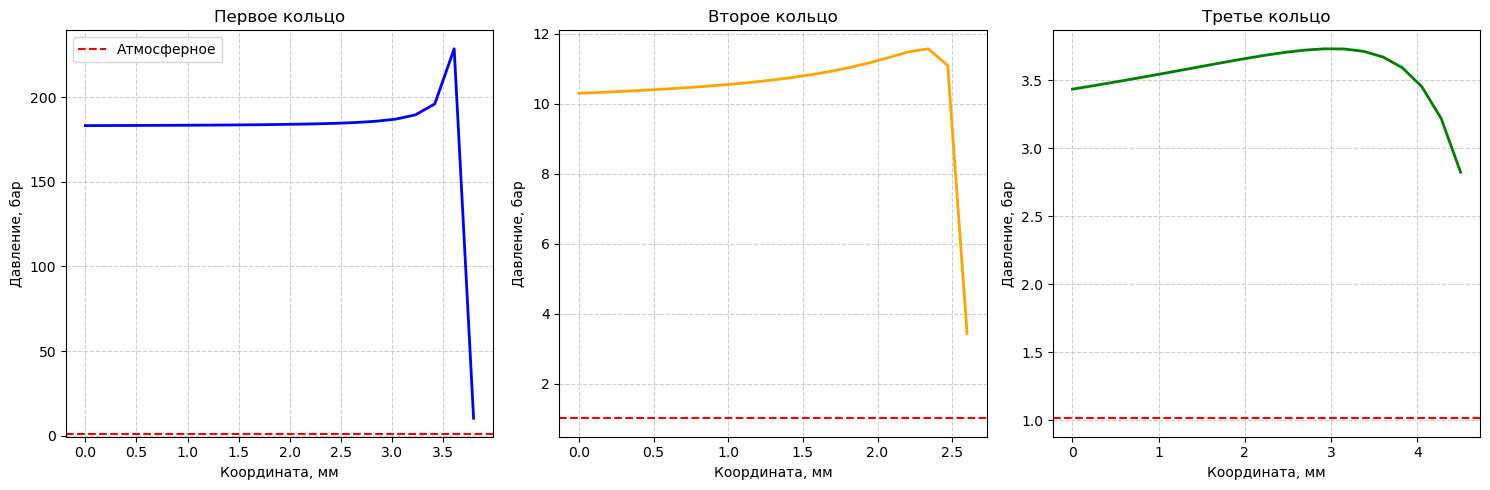

In [579]:
idx_max_p = np.argmax(P_cyl)
print(f"Характерный угол: {angle_deg[idx_max_p]:.1f} ° (максимум давления в цилиндре)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ring_names = ['Первое кольцо', 'Второе кольцо', 'Третье кольцо']
colors = ['blue', 'orange', 'green']

for k in range(3):
    prof = profiles[k]
    xv = x_vals_list[k]
    if k == 0:
        p_in = P_cyl[idx_max_p]
        p_out = P_land1[idx_max_p]
        p_back = max(p_in, p_out)
    elif k == 1:
        p_in = P_land1[idx_max_p]
        p_out = P_land2[idx_max_p]
        p_back = max(p_in, p_out)
    else:
        p_in = P_land2[idx_max_p]
        p_out = P_land3[idx_max_p]
        p_back = max(p_in, p_out)

    U_typ = abs(v_piston[idx_max_p])
    mu_typ = oil_viscosity(T_ring_zone[k])
    h_eq_typ = find_equilibrium_h(prof, xv, U_typ, mu_typ, p_in, p_out, p_back, F_elastic[k])
    h_total_typ = prof + h_eq_typ
    dx_typ = xv[1] - xv[0]
    p_dist, _ = solve_reynolds_steady(h_total_typ, U_typ, mu_typ, p_in, p_out, dx_typ)

    ax = axes[k]
    ax.plot(xv * 1000, p_dist / 1e5, color=colors[k], linewidth=2)
    ax.set_xlabel('Координата, мм')
    ax.set_ylabel('Давление, бар')
    ax.set_title(ring_names[k])
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.axhline(y=1.01325, color='r', linestyle='--', label='Атмосферное')
    if k == 0:
        ax.legend()
plt.tight_layout()
plt.show()

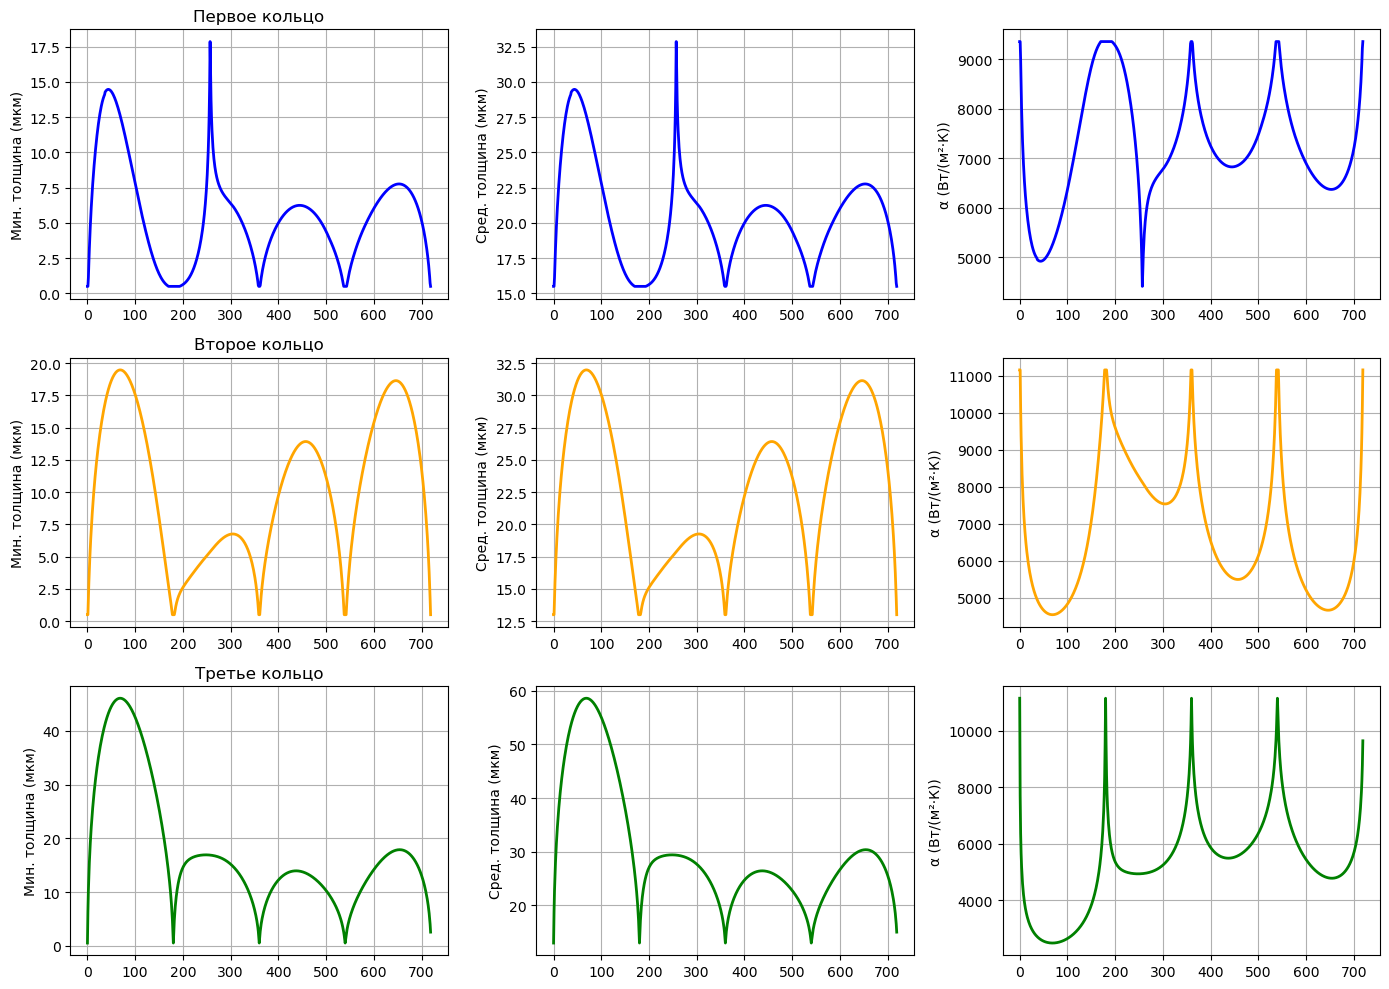


========== Экстремальные толщины масляной плёнки (мкм) ==========
Первое кольцо: мин. = 15.50 мкм, макс. = 32.86 мкм, сред. = 20.51 мкм
Второе кольцо: мин. = 13.00 мкм, макс. = 31.97 мкм, сред. = 22.81 мкм
Третье кольцо: мин. = 13.00 мкм, макс. = 58.59 мкм, сред. = 30.46 мкм
====== Средние коэффициенты теплоотдачи (Вт/(м²·К)) ======
Первое кольцо: α_ср = 7266.51
Второе кольцо: α_ср = 6782.43
Третье кольцо: α_ср = 5340.89


In [580]:
ring_labels = ['Первое кольцо', 'Второе кольцо', 'Третье кольцо']
colors = ['blue', 'orange', 'green']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for k in range(3):
    h_min_um  = h_min_ring[k] * 1e6
    h_mean_um = h_mean_ring[k] * 1e6

    ax1 = axes[k, 0]
    ax1.plot(angle_deg, h_min_um, color=colors[k], linewidth=2)
    ax1.set_ylabel('Мин. толщина (мкм)')
    ax1.set_title(ring_labels[k])
    ax1.grid(True)

    ax2 = axes[k, 1]
    ax2.plot(angle_deg, h_mean_um, color=colors[k], linewidth=2)
    ax2.set_ylabel('Сред. толщина (мкм)')
    ax2.grid(True)

    ax3 = axes[k, 2]
    ax3.plot(angle_deg, alpha_ring[k], color=colors[k], linewidth=2)
    ax3.set_ylabel('α (Вт/(м²·К))')
    ax3.grid(True)
plt.tight_layout()
plt.show()

# ---- Статистика толщин и теплоотдачи ----
print("\n========== Экстремальные толщины масляной плёнки (мкм) ==========")
for k in range(3):
    h_um = h_mean_ring[k] * 1e6
    print(f"{ring_labels[k]}: мин. = {np.min(h_um):.2f} мкм, "
          f"макс. = {np.max(h_um):.2f} мкм, "
          f"сред. = {np.mean(h_um):.2f} мкм")

print("====== Средние коэффициенты теплоотдачи (Вт/(м²·К)) ======")
for k in range(3):
    print(f"{ring_labels[k]}: α_ср = {np.mean(alpha_ring[k]):.2f}")